In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

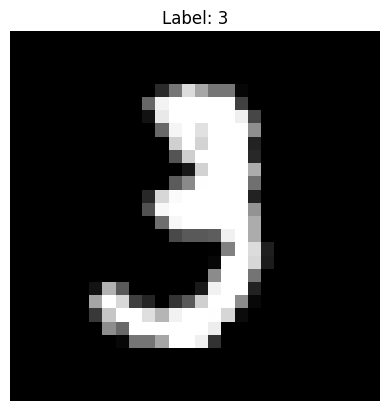

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# This our Mnist dataset is look like in actual format.
plt.imshow(x_train[10], cmap='gray')
plt.title(f'Label: {y_train[10]}')
plt.axis('off')
plt.show()

In [3]:
import pandas as pd
data = {'Optimizer': [],'Loss_Function': [],'Accuracy': []}
df = pd.DataFrame(data)

In [15]:
def CNN():
    # Load and preprocess the MNIST dataset
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test = x_test.reshape(-1, 28, 28, 1)
    y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
    
    # Define possible optimizers and loss functions
    optimizers = ['adam', 'sgd', 'rmsprop']
    losses = ['categorical_crossentropy','mean_squared_error'] # If your accuracy is still low you can add more cost functions 
    
    best_accuracy = 0.0
    best_optimizer = ''
    best_loss = ''
    score = []
    # Iterate through optimizers and losses to find the best combination
    for optimizer in optimizers:
        for loss in losses:
            print(f"Training with optimizer: {optimizer}, loss: {loss}")
            
            # Create and compile the model
            model = models.Sequential([
                layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(64, (3, 3), activation='relu'),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(64, (3, 3), activation='relu'),
                layers.Flatten(),
                layers.Dense(64, activation='relu'),
                layers.Dense(10, activation='softmax')
            ])
            model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
            
            # Train the model with early stopping 
            # restore_best_weights means that if the validation loss does not improve for a certain number of epochs, training will stop and the best weights will be restored.
            early_stopping = EarlyStopping(patience=3, restore_best_weights=True)
            model.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[early_stopping])
            
            # Evaluate on test data
            accuracy = model.evaluate(x_test, y_test, verbose=0)[1] # [1] gets the accuracy metric                        
            new_data = {'Optimizer': optimizer,'Loss_Function': loss,'Accuracy': accuracy}
            score.append(new_data)
                        
            # Update best parameters if accuracy is improved
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_optimizer = optimizer
                best_loss = loss
    global df
    df = pd.DataFrame(score)
    print(f"Best optimizer: {best_optimizer}, Best loss: {best_loss}, Best accuracy: {best_accuracy:.4f}")
    
# Call the function to train CNN with best parameters
CNN()

Training with optimizer: adam, loss: categorical_crossentropy


c:\Workspace\MyProjects\DeepLearning\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8820 - loss: 0.3836 - val_accuracy: 0.9805 - val_loss: 0.0651
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9852 - loss: 0.0490 - val_accuracy: 0.9833 - val_loss: 0.0637
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9878 - loss: 0.0369 - val_accuracy: 0.9852 - val_loss: 0.0511
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9862 - val_loss: 0.0521
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9869 - val_loss: 0.0490
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9949 - loss: 0.0150 - val_accuracy: 0.9858 - val_loss: 0.0507
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9960 - loss: 0.0119 - val_accuracy: 0.9845 - val_loss: 0.0615
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9960 - 

In [16]:
df

,Optimizer,Loss_Function,Accuracy
0,adam,categorical_crossentropy,0.9906
1,adam,mean_squared_error,0.9898
2,sgd,categorical_crossentropy,0.9852
3,sgd,mean_squared_error,0.8950
4,rmsprop,categorical_crossentropy,0.9902
5,rmsprop,mean_squared_error,0.9889


In [17]:
# best result by each optimizer is
df.groupby('Optimizer')['Accuracy'].max()

Optimizer
adam       0.9906
rmsprop    0.9902
sgd        0.9852
Name: Accuracy, dtype: float64

**Conclusion:** As we tried diffrent combination with loss functions and optimizers, **adam** is the best optimizer along with  **categorical_crossentropy** as loss function wich gives maximum accuracy around **0.9906** among diffrent models.